# Download dataset

In [1]:
!pip install -U spacy==3.*
!python -m spacy download en_core_web_sm
!python -m spacy info
!pip install -U gensim==4.*

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 119.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

============================== Info about spaCy ==============================

spaCy version    3.8.11                        
Location         /usr/local/lib/python3.12/dist-packages/spacy
Platform         Linux-6.6.113+-x86_64-with-glibc2.35
Python version   3.12.12                       
Pipelines        en_core_web_sm (3.8.0)        

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 84.7 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import random
import spacy
import numpy as np

from gensim import models, corpora
from gensim import similarities
from gensim.models.coherencemodel import CoherenceModel
from wordcloud import WordCloud

In [3]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"

locale.getpreferredencoding = getpreferredencoding

In [4]:
!pip install --upgrade --no-cache-dir gdown

In [5]:
# Download the CNN corpus.
!gdown 'https://drive.google.com/uc?id=122fC9XpNwFKx0ryRVKJz5MWUTzA3Vpsf'

Downloading...
From (original): https://drive.google.com/uc?id=122fC9XpNwFKx0ryRVKJz5MWUTzA3Vpsf
From (redirected): https://drive.google.com/uc?id=122fC9XpNwFKx0ryRVKJz5MWUTzA3Vpsf&confirm=t&uuid=b47052fe-b119-49f3-b520-5da236b6ccc1
To: /content/cnn_articles.txt
100% 365M/365M [00:03<00:00, 91.4MB/s]


In [6]:
with open('cnn_articles.txt', 'r', encoding='utf8') as f:
  articles = f.read().split('@delimiter')

In [7]:
DATASET_SIZE = 500
dataset = articles[:DATASET_SIZE]

In [8]:
spacy.require_gpu()

True

# Before preprocessing

In [9]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def basic_filter(tokenized_doc):
  return [t.lemma_ for t in tokenized_doc if
          t.is_alpha and \
          not t.is_punct and \
          not t.is_space]

In [10]:
%%time
tokenized_articles = list(map(basic_filter, nlp.pipe(dataset, batch_size = 512)))
tokenized_articles = [doc for doc in tokenized_articles if len(doc) != 0]

CPU times: user 17.9 s, sys: 209 ms, total: 18.1 s
Wall time: 18.3 s


In [11]:
N = len(tokenized_articles)
print("Number of documents (N):", N)

# Total tokens
total_tokens = sum(len(doc) for doc in tokenized_articles)
print("Total tokens:", total_tokens)

# Vocabulary
vocab = corpora.Dictionary(tokenized_articles)
V = len(vocab)
print("Vocabulary size (|V|):", V)

# Document lengths
lengths = [len(doc) for doc in tokenized_articles]

# Statistics
avg_length = np.mean(lengths)
std_length = np.std(lengths)
print("Average document length:", avg_length)
print("Std document length:", std_length)

Number of documents (N): 500
Total tokens: 313220
Vocabulary size (|V|): 19555
Average document length: 626.44
Std document length: 333.0864428342889


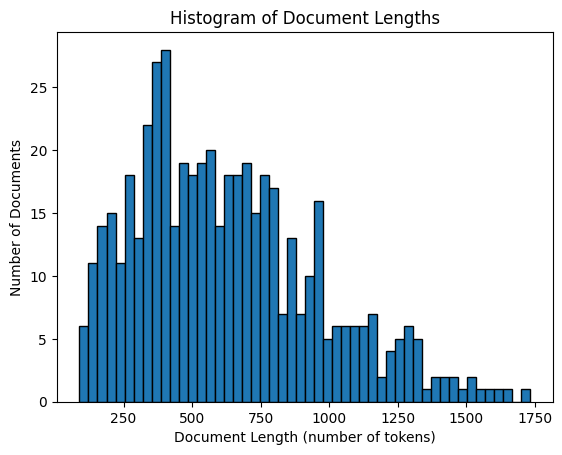

In [12]:
lengths = [len(doc) for doc in tokenized_articles]

plt.hist(lengths, bins=50, edgecolor = 'black')
plt.xlabel("Document Length (number of tokens)")
plt.ylabel("Number of Documents")
plt.title("Histogram of Document Lengths")
plt.show()

# After preprocessing

In [13]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def improved_filter(tokenized_doc):
  return [t.lemma_ for t in tokenized_doc if
          t.is_alpha and \
          not t.is_punct and \
          not t.is_space and \
          not t.is_stop and \
          t.pos_ in ['NOUN', 'VERB', 'ADJ']]

In [14]:
%%time
pre_tokenized_articles = list(map(improved_filter, nlp.pipe(dataset, batch_size = 512)))
pre_tokenized_articles = [doc for doc in pre_tokenized_articles if len(doc) != 0]

CPU times: user 15 s, sys: 28.3 ms, total: 15 s
Wall time: 15.1 s


In [16]:
pre_N = len(pre_tokenized_articles)
print("Number of documents (N):", pre_N)

# Total tokens
pre_total_tokens = sum(len(doc) for doc in pre_tokenized_articles)
print("Total tokens:", pre_total_tokens)

# Vocabulary
pre_vocab = corpora.Dictionary(pre_tokenized_articles)
pre_V = len(pre_vocab)
print("Vocabulary size (|V|):", pre_V)

# Vocabulary after filtering extreme word
pre_vocab.filter_extremes(no_below=5, no_above=0.5)
pre_V = len(pre_vocab)
print("Vocabulary size after filtering extreme word (|V|):", pre_V)

# Document lengths
pre_lengths = [len(doc) for doc in pre_tokenized_articles if len(doc) != 0]

# Statistics
pre_avg_length = np.mean(pre_lengths)
pre_std_length = np.std(pre_lengths)
print("Average document length:", pre_avg_length)
print("Std document length:", pre_std_length)

Number of documents (N): 500
Total tokens: 120937
Vocabulary size (|V|): 10726
Vocabulary size after filtering extreme word (|V|): 3033
Average document length: 241.874
Std document length: 130.6543306744939


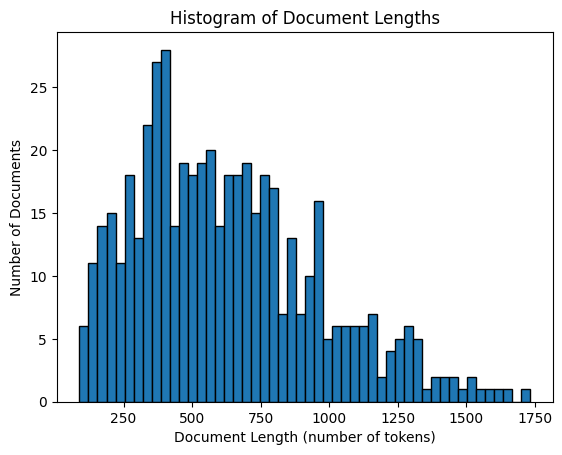

In [17]:
lengths = [len(doc) for doc in tokenized_articles]

plt.hist(lengths, bins=50, edgecolor = 'black')
plt.xlabel("Document Length (number of tokens)")
plt.ylabel("Number of Documents")
plt.title("Histogram of Document Lengths")
plt.show()

# Compare before and after

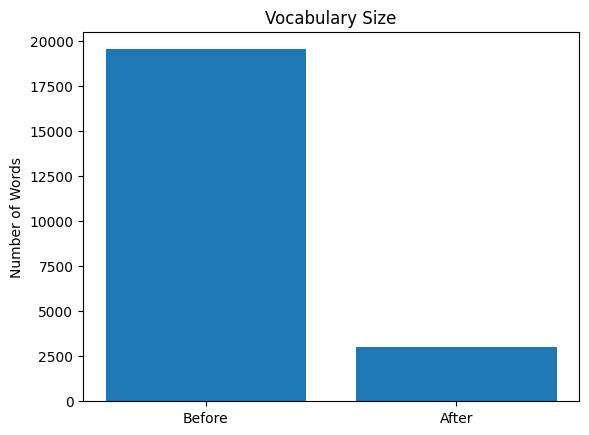

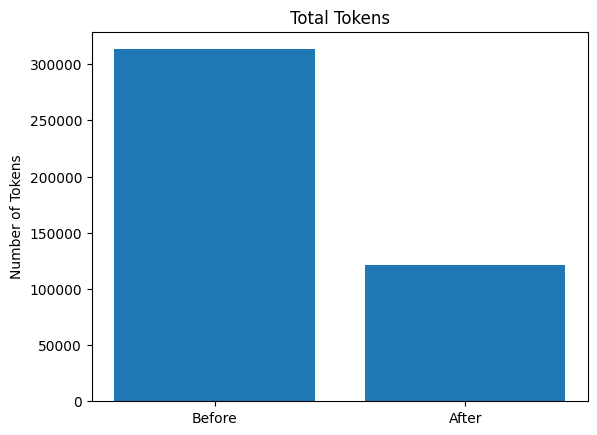

In [18]:
# Vocabulary
plt.bar(["Before","After"], [V, pre_V])
plt.title("Vocabulary Size")
plt.ylabel("Number of Words")
plt.show()

# Tokens
plt.bar(["Before","After"], [total_tokens, pre_total_tokens])
plt.title("Total Tokens")
plt.ylabel("Number of Tokens")
plt.show()

# Save preprocessed data

In [24]:
%%time
import pickle
import os

filename = 'preprocessed_data_for_LDA.pkl'

with open(filename, 'wb') as f:
    pickle.dump(pre_tokenized_articles, f)
print(f"Processed and saved tokenized_articles to {filename}.")

Processed and saved tokenized_articles to preprocessed_data_for_LDA.pkl.
CPU times: user 25.6 ms, sys: 780 µs, total: 26.4 ms
Wall time: 29.9 ms


In [26]:
%%time
# Save preprocessed data for Trie

filename = 'preprocessed_data_for_Trie.pkl'

def trie_filter(tokenized_doc):
  return [t.text for t in tokenized_doc if
          t.is_alpha and \
          not t.is_punct and \
          not t.is_space]

tokenized_articles = list(map(trie_filter, nlp.pipe(dataset, batch_size = 512)))
tokenized_articles = [doc for doc in tokenized_articles if len(doc) != 0]

with open(filename, 'wb') as f:
    pickle.dump(tokenized_articles, f)
print(f"Processed and saved tokenized_articles to {filename}.")

Processed and saved tokenized_articles to preprocessed_data_for_Trie.pkl.
CPU times: user 10.5 s, sys: 2.29 ms, total: 10.5 s
Wall time: 10.5 s
